# SVD (Singular Value Decomposition) — notatnik referencyjny

Notatnik w tym samym duchu co notebook o macierzy kowariancji i PCA: definicje,
dowody, weryfikacja numpy na konkretnych liczbach. Punkt wyjscia to kod ktory juz
widziales (SVD na returns_big), a potem idziemy dalej.

**Struktura:**
1. Definicja SVD i dlaczego istnieje dla KAZDEJ macierzy (nie tylko symetrycznej)
2. Pelne SVD vs thin SVD — co dokladnie zwraca numpy
3. Zwiazek SVD z eigendecomposition (czemu S^2/(N-1) = eigenvalues Sigma)
4. Rekonstrukcja low-rank i norma Frobeniusa — dowod twierdzenia Eckart-Young
5. Geometria SVD: macierz jako obrot-skalowanie-obrot
6. Noise filtering i denoising — kiedy to dziala a kiedy nie
7. Dalej: SVD do rozwiazywania ukladow rownan (pseudoinverse), rekomendacje

---


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__)


NumPy 2.4.4


---
## 1. Definicja SVD

### 1.1 Czym SVD rozni sie od eigendecomposition

Eigendecomposition ($A = V\Lambda V^T$) dziala tylko dla macierzy **kwadratowych i
symetrycznych** (twierdzenie spektralne z poprzedniego notebooka).

SVD dziala dla **kazdej** macierzy prostokatnej $A$ o wymiarach $(m \times n)$ — nie musi
byc kwadratowa, nie musi byc symetryczna. To jest powod czemu SVD jest uzywane szerzej:
dane w finansach to zazwyczaj $(T \times N)$ — $T$ dni, $N$ aktywow, gdzie $T \neq N$.

### 1.2 Twierdzenie (istnienie SVD)

Dla kazdej macierzy rzeczywistej $A$ $(m \times n)$ istnieja macierze:

$$
A = U \Sigma V^T
$$

gdzie:
- $U$ $(m \times m)$ — **ortogonalna** ($U^TU = UU^T = I$), kolumny to *left singular vectors*
- $\Sigma$ $(m \times n)$ — **diagonalna** (w sensie prostokatnym: niezerowe tylko na "przekatnej"
  $\Sigma_{ii}$), wartosci $\sigma_1 \geq \sigma_2 \geq ... \geq 0$ to *singular values*
- $V$ $(n \times n)$ — **ortogonalna** ($V^TV = VV^T = I$), kolumny to *right singular vectors*

**Uwaga notacyjna:** uzywamy $\Sigma$ tu dla macierzy diagonalnej z singular values — to NIE
jest macierz kowariancji z poprzedniego notebooka, mimo tego samego symbolu (konwencja
w literaturze SVD, troche niefortunna, ale powszechna).


### 1.3 Skad SVD w ogole istnieje — szkic dowodu przez $A^TA$

Kluczowy trik: zamiast dekomponowac $A$ wprost (co jest trudne bo $A$ nie jest symetryczna),
budujemy z niej macierz **symetryczna** $A^TA$ ($n \times n$) i stosujemy do niej twierdzenie
spektralne z poprzedniego notebooka.

**Krok 1.** $A^TA$ jest symetryczna: $(A^TA)^T = A^TA$. ✓ (transpozycja iloczynu odwraca
kolejnosc i transponuje kazdy czynnik, $(A^T)^T=A$)

**Krok 2.** $A^TA$ jest PSD: dla kazdego $\mathbf{x}$, $\mathbf{x}^T(A^TA)\mathbf{x} =
(A\mathbf{x})^T(A\mathbf{x}) = \|A\mathbf{x}\|^2 \geq 0$. (To jest dokladnie ten sam
argument co dowod PSD macierzy kowariancji w poprzednim notebooku — kwadrat normy zawsze
nieujemny.)

**Krok 3.** Z twierdzenia spektralnego: $A^TA = V\Lambda V^T$ dla pewnych ortogonalnych $V$
i nieujemnych eigenvalues $\lambda_i \geq 0$ (PSD => nieujemne eigenvalues, dokladnie jak
w Sekcji 4.4 poprzedniego notebooka).

**Krok 4.** Definiujemy $\sigma_i = \sqrt{\lambda_i}$ (singular values to pierwiastki
eigenvalues $A^TA$) i $\mathbf{u}_i = \frac{1}{\sigma_i}A\mathbf{v}_i$ (left singular
vectors konstruowane z right singular vectors). Mozna sprawdzic ze ten zestaw $U, \Sigma, V$
spelnia $A = U\Sigma V^T$.

Nie przeprowadzamy tu pelnego dowodu formalnego (wymaga troche wiecej algebry), ale kluczowa
idea — $A^TA$ jest symetryczna, wiec ma dekompozycje spektralna, a z niej wyprowadza sie
cala SVD — jest tym co warto zapamietac.


In [2]:
# --- Weryfikacja: A^T A jest symetryczna i PSD, dla DOWOLNEJ (niekwadratowej!) A ---

A_test = np.array([
    [1.0, 2.0, 0.0],
    [0.0, 1.0, 3.0],
    [2.0, 0.0, 1.0],
    [1.0, 1.0, 1.0],
])   # (4, 3) -- NIEKWADRATOWA, niesymetryczna

print(f"A.shape: {A_test.shape}  <- prostokatna, m != n mozliwe")
print()

AtA = A_test.T @ A_test   # (3,4) @ (4,3) = (3,3)
print(f"A^T A shape: {AtA.shape}  <- zawsze KWADRATOWA (n x n)")
print()
print("A^T A:")
print(AtA)
print()
print(f"Symetryczna (A^T A == (A^T A)^T): {np.allclose(AtA, AtA.T)}")

eigenvalues_AtA = np.linalg.eigvalsh(AtA)
print(f"\nEigenvalues A^T A: {eigenvalues_AtA.round(6)}")
print(f"Wszystkie >= 0 (PSD): {np.all(eigenvalues_AtA >= -1e-10)}")


A.shape: (4, 3)  <- prostokatna, m != n mozliwe

A^T A shape: (3, 3)  <- zawsze KWADRATOWA (n x n)

A^T A:
[[ 6.  3.  3.]
 [ 3.  6.  4.]
 [ 3.  4. 11.]]

Symetryczna (A^T A == (A^T A)^T): True

Eigenvalues A^T A: [ 2.8786  5.0468 15.0746]
Wszystkie >= 0 (PSD): True


In [3]:
# --- Singular values to pierwiastki eigenvalues A^T A ---

U, S, Vt = np.linalg.svd(A_test, full_matrices=False)

print("Singular values z np.linalg.svd:")
print(S.round(6))
print()
print("sqrt(eigenvalues A^T A), sortowane malejaco:")
eigvals_sorted = np.sort(eigenvalues_AtA)[::-1]
print(np.sqrt(np.maximum(eigvals_sorted, 0)).round(6))
print()
print(f"Identyczne: {np.allclose(S, np.sqrt(np.maximum(eigvals_sorted, 0)))}")


Singular values z np.linalg.svd:
[3.8826 2.2465 1.6966]

sqrt(eigenvalues A^T A), sortowane malejaco:
[3.8826 2.2465 1.6966]

Identyczne: True


---
## 2. Pelne SVD vs thin SVD

### 2.1 Co dokladnie zwraca np.linalg.svd

Dla $A$ $(m \times n)$ z $m > n$ (jak nasze dane: $T=504$ dni $> N=10$ aktywow):

**Pelne SVD** (`full_matrices=True`, domyslne):
$$
U: (m \times m), \quad \Sigma: (m \times n), \quad V^T: (n \times n)
$$

**Thin SVD** (`full_matrices=False`):
$$
U: (m \times k), \quad S: (k,), \quad V^T: (k \times n), \quad k = \min(m,n)
$$

`S` to **wektor** (1D), nie macierz — numpy nie zwraca calej $\Sigma$ z zerami, tylko
niezerowe wartosci na przekatnej. Trzeba samemu zbudowac `np.diag(S)` jesli potrzebna
pelna macierz diagonalna.

### 2.2 Dlaczego thin SVD wystarcza w praktyce

Kolumny $U$ od $k+1$ do $m$ (te ktore thin SVD odcina) sa mnozone przez **zera** w pelnej
$\Sigma$ — wiec nie wnosza nic do iloczynu $U\Sigma V^T$. Innymi slowy, te dodatkowe
kolumny to "martwa waga" obliczeniowa.


In [4]:
# --- Pelne vs thin SVD na tej samej macierzy ---

A = np.array([
    [1.0, 2.0, 0.0],
    [0.0, 1.0, 3.0],
    [2.0, 0.0, 1.0],
    [1.0, 1.0, 1.0],
])   # (4, 3), m=4 > n=3

U_full, S_full, Vt_full = np.linalg.svd(A, full_matrices=True)
U_thin, S_thin, Vt_thin = np.linalg.svd(A, full_matrices=False)

print("PELNE SVD:")
print(f"  U.shape:  {U_full.shape}   (m x m = 4x4)")
print(f"  S.shape:  {S_full.shape}   (k,) = (3,) -- TEN SAM rozmiar w obu wersjach!")
print(f"  Vt.shape: {Vt_full.shape}   (n x n = 3x3)")
print()
print("THIN SVD:")
print(f"  U.shape:  {U_thin.shape}   (m x k = 4x3)")
print(f"  S.shape:  {S_thin.shape}   (k,) = (3,)")
print(f"  Vt.shape: {Vt_thin.shape}   (k x n = 3x3, identyczne jak pelne bo n=k tutaj)")


PELNE SVD:
  U.shape:  (4, 4)   (m x m = 4x4)
  S.shape:  (3,)   (k,) = (3,) -- TEN SAM rozmiar w obu wersjach!
  Vt.shape: (3, 3)   (n x n = 3x3)

THIN SVD:
  U.shape:  (4, 3)   (m x k = 4x3)
  S.shape:  (3,)   (k,) = (3,)
  Vt.shape: (3, 3)   (k x n = 3x3, identyczne jak pelne bo n=k tutaj)


In [5]:
# --- Weryfikacja rekonstrukcji w obu wersjach ---

# Pelna: trzeba zbudowac Sigma jako (m,n) prostokatna macierz z zerami
Sigma_full = np.zeros((4, 3))
Sigma_full[:3, :3] = np.diag(S_full)   # niezerowe tylko na "przekatnej" k x k
A_reconstructed_full = U_full @ Sigma_full @ Vt_full

print("Rekonstrukcja z PELNEGO SVD:")
print(A_reconstructed_full.round(4))
print(f"Identyczne z A: {np.allclose(A_reconstructed_full, A)}")

print()

# Thin: S to wektor (k,), trzeba zrobic np.diag recznie
A_reconstructed_thin = U_thin @ np.diag(S_thin) @ Vt_thin
print("\nRekonstrukcja z THIN SVD:")
print(A_reconstructed_thin.round(4))
print(f"Identyczne z A: {np.allclose(A_reconstructed_thin, A)}")


Rekonstrukcja z PELNEGO SVD:
[[ 1.  2.  0.]
 [-0.  1.  3.]
 [ 2. -0.  1.]
 [ 1.  1.  1.]]
Identyczne z A: True


Rekonstrukcja z THIN SVD:
[[ 1.  2.  0.]
 [-0.  1.  3.]
 [ 2. -0.  1.]
 [ 1.  1.  1.]]
Identyczne z A: True


In [6]:
# --- Co jest w "odcietych" kolumnach U przy thin SVD ---
# Pelne U ma 4 kolumny, thin ma tylko 3 -- co bylo w 4-tej kolumnie?

print("Pelne U (4x4):")
print(U_full.round(4))
print()
print("4-ta kolumna pelnego U (ta ktora thin SVD odcina):")
print(U_full[:, 3].round(4))
print()
print("Ta kolumna jest mnozona przez wiersz zer w Sigma_full (bo Sigma jest (4,3), wiersz 3 to same zera):")
print(Sigma_full[3, :])
print("-> wklad tej kolumny do U @ Sigma @ Vt to ZERO, bez wzgledu na jej wartosci")


Pelne U (4x4):
[[-0.353   0.6549  0.5764 -0.3379]
 [-0.7216 -0.6406  0.1671 -0.2027]
 [-0.4128  0.342  -0.7998 -0.2703]
 [-0.4293  0.2093  0.0142  0.8785]]

4-ta kolumna pelnego U (ta ktora thin SVD odcina):
[-0.3379 -0.2027 -0.2703  0.8785]

Ta kolumna jest mnozona przez wiersz zer w Sigma_full (bo Sigma jest (4,3), wiersz 3 to same zera):
[0. 0. 0.]
-> wklad tej kolumny do U @ Sigma @ Vt to ZERO, bez wzgledu na jej wartosci


---
## 3. Zwiazek SVD z eigendecomposition macierzy kowariancji

### 3.1 Skad bierze sie wzor S^2/(N-1) = eigenvalues(Sigma)

To jest dokladnie ten kod ktory juz widziales. Wyprowadzmy go formalnie.

Dla danych wycentrowanych $R_c$ $(T \times N)$ (T obserwacji, N zmiennych), macierz
kowariancji to:

$$
\hat\Sigma = \frac{1}{T-1} R_c^T R_c
$$

(To jest ten sam wzor $\hat\Sigma = \frac{1}{N-1}X_cX_c^T$ z poprzedniego notebooka,
tylko tu $R_c$ ma obserwacje w **wierszach** (konwencja T x N), wiec transpozycja jest
po drugiej stronie.)

Podstawiajac SVD $R_c = U\Sigma_{svd} V^T$ (gdzie $\Sigma_{svd}$ to macierz singular values,
zeby nie mylic z $\hat\Sigma$):

$$
R_c^TR_c = (U\Sigma_{svd}V^T)^T(U\Sigma_{svd}V^T) = V\Sigma_{svd}^TU^TU\Sigma_{svd}V^T
$$

Skoro $U^TU=I$ (ortogonalnosc U):

$$
R_c^TR_c = V\Sigma_{svd}^T\Sigma_{svd}V^T = V \, \text{diag}(\sigma_i^2) \, V^T
$$

Wiec:

$$
\hat\Sigma = \frac{1}{T-1}V\,\text{diag}(\sigma_i^2)\,V^T
$$

Porownujac z dekompozycja spektralna $\hat\Sigma = V_\Sigma \Lambda V_\Sigma^T$
(z poprzedniego notebooka) — **te dwie dekompozycje musza byc identyczne** (z dokladnoscia
do znaku kolumn), bo dekompozycja spektralna jest unikalna dla niezdegenerowanych
eigenvalues. Stad:

$$
\lambda_i = \frac{\sigma_i^2}{T-1} \qquad \text{oraz} \qquad V = V_\Sigma
$$

Czyli: **right singular vectors $V$ z SVD danych = eigenvectory macierzy kowariancji**,
a **eigenvalues = singular values$^2$ / (T-1)**.


In [7]:
# --- Pelna weryfikacja na returns_big-podobnych danych ---
np.random.seed(42)

T, N = 504, 10
market_factor = np.random.normal(0, 0.01, T)
betas = np.random.uniform(0.5, 1.5, N)
returns_big = (betas[:, np.newaxis] * market_factor[np.newaxis, :]
               + np.random.normal(0, 0.008, (N, T))).T   # (504, 10)

R_centered = returns_big - returns_big.mean(axis=0)

# Metoda 1: eigendecomposition macierzy kowariancji
Sigma_cov = np.cov(R_centered.T)
evals_eig, evecs_eig = np.linalg.eigh(Sigma_cov)
idx = np.argsort(evals_eig)[::-1]
evals_eig = evals_eig[idx]
evecs_eig = evecs_eig[:, idx]

# Metoda 2: SVD danych
U, S, Vt = np.linalg.svd(R_centered, full_matrices=False)
evals_svd = S**2 / (T - 1)
V_svd = Vt.T   # kolumny V to right singular vectors

print("Eigenvalues -- porownanie:")
print(f"  Z eigh(Sigma):     {evals_eig[:5].round(8)}")
print(f"  Z SVD (S^2/(T-1)): {evals_svd[:5].round(8)}")
print(f"  Identyczne: {np.allclose(evals_eig, evals_svd)}")


Eigenvalues -- porownanie:
  Z eigh(Sigma):     [0.0007 0.0001 0.0001 0.0001 0.0001]
  Z SVD (S^2/(T-1)): [0.0007 0.0001 0.0001 0.0001 0.0001]
  Identyczne: True


In [8]:
# --- Eigenvectory vs right singular vectors -- moga sie roznic znakiem ---
print("Eigenvector PC1 (z eigh):", evecs_eig[:, 0].round(4))
print("Right singular vector 1 (z SVD):", V_svd[:, 0].round(4))
print()

# Eigenvectory sa unikalne "do znaku" -- v i -v sa OBA poprawnymi eigenvectorami
same_sign = np.allclose(evecs_eig[:, 0], V_svd[:, 0])
opposite_sign = np.allclose(evecs_eig[:, 0], -V_svd[:, 0])
print(f"Identyczne (ten sam znak):     {same_sign}")
print(f"Identyczne (odwrotny znak):    {opposite_sign}")
print(f"\n-> Wektory sa 'tym samym kierunkiem' niezaleznie od konwencji znaku,")
print(f"   bo v i -v opisuja TA SAMA os w przestrzeni (kluczowe: SAMA linia, dwa kierunki)")


Eigenvector PC1 (z eigh): [0.2347 0.2519 0.2726 0.2466 0.284  0.3131 0.2561 0.5334 0.2274 0.4072]
Right singular vector 1 (z SVD): [-0.2347 -0.2519 -0.2726 -0.2466 -0.284  -0.3131 -0.2561 -0.5334 -0.2274
 -0.4072]

Identyczne (ten sam znak):     False
Identyczne (odwrotny znak):    True

-> Wektory sa 'tym samym kierunkiem' niezaleznie od konwencji znaku,
   bo v i -v opisuja TA SAMA os w przestrzeni (kluczowe: SAMA linia, dwa kierunki)


### 3.2 Czy U cos znaczy finansowo?

$U$ ($T \times K$) to **left singular vectors** — opisuja jak kazdy z $K$ czynnikow
zmienia sie **w czasie**. Kolumna $U[:, i]$ to znormalizowany szereg czasowy $i$-tego
czynnika (do dlugosci 1).

Zwiazek z PC scores z poprzedniego notebooka: $PC_i\text{-scores} = R_c V[:,i] = \sigma_i U[:,i]$
— czyli $U$ to PC scores **znormalizowane** (podzielone przez $\sigma_i$).


In [9]:
# --- Weryfikacja: PC scores = sigma_i * U[:,i] ---

pc_scores_direct = R_centered @ V_svd[:, :3]   # projekcja danych na pierwsze 3 PC
pc_scores_from_U = U[:, :3] * S[:3]            # broadcasting: kazda kolumna U razy odpowiadajacy sigma

print("PC scores (R_c @ V), pierwsze 3 wiersze:")
print(pc_scores_direct[:3].round(4))
print()
print("sigma * U, pierwsze 3 wiersze:")
print(pc_scores_from_U[:3].round(4))
print()
print(f"Identyczne: {np.allclose(pc_scores_direct, pc_scores_from_U)}")


PC scores (R_c @ V), pierwsze 3 wiersze:
[[-0.006  -0.0138  0.0063]
 [ 0.003   0.0009 -0.0087]
 [-0.0239  0.0008 -0.0154]]

sigma * U, pierwsze 3 wiersze:
[[-0.006  -0.0138  0.0063]
 [ 0.003   0.0009 -0.0087]
 [-0.0239  0.0008 -0.0154]]

Identyczne: True


---
## 4. Rekonstrukcja low-rank i twierdzenie Eckart-Young

### 4.1 SVD jako suma macierzy rank-1

Dokladnie jak macierz kowariancji byla suma $\sum_i \lambda_i \mathbf{v}_i\mathbf{v}_i^T$
(Sekcja 4.3 poprzedniego notebooka), kazda macierz $A$ ma analogiczny rozklad przez SVD:

$$
A = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T
$$

Kazdy skladnik $\sigma_i\mathbf{u}_i\mathbf{v}_i^T$ to macierz **rangi 1** (outer product
przeskalowany przez $\sigma_i$). Singular values sa posortowane malejaco, wiec **pierwsze
skladniki niosa najwiecej "energii" macierzy**.

### 4.2 Aproksymacja rangi K

Obcinajac sume do $K < k$ skladnikow:

$$
A_K = \sum_{i=1}^{K} \sigma_i \mathbf{u}_i \mathbf{v}_i^T = U_K \Sigma_K V_K^T
$$

$A_K$ ma rzad (rank) co najwyzej $K$ — to jest **najlepsza mozliwa** aproksymacja $A$
o tym rzedzie, w sensie ktory precyzuje nastepujace twierdzenie.

### 4.3 Twierdzenie Eckart-Young (1936)

Wsrod **wszystkich** macierzy $B$ o rzedzie $\leq K$, macierz $A_K$ (zbudowana z SVD,
obcieta do $K$ wyrazow) minimalizuje blad w normie Frobeniusa:

$$
A_K = \arg\min_{B: \text{rank}(B) \leq K} \|A - B\|_F
$$

i wartosc tego minimalnego bledu to:

$$
\|A - A_K\|_F = \sqrt{\sum_{i=K+1}^{k} \sigma_i^2}
$$

**To jest powod czemu SVD jest "optymalne" do kompresji/redukcji wymiaru** — nie ma
zadnej innej macierzy niskiej rangi ktora lepiej przyblizy $A$ w sensie Frobeniusa.
Nie dowodzimy tego tutaj formalnie (dowod wymaga troche wiecej pracy), ale **weryfikujemy
empirycznie** ponizej -- sprawdzamy ze SVD bije inne (losowe) aproksymacje rangi K.


In [10]:
# --- Definicja normy Frobeniusa ---
# ||A||_F = sqrt(sum of squared elements) = sqrt(trace(A^T A))

A_sample = np.array([[3.0, 4.0], [0.0, 0.0]])

fro_direct = np.sqrt(np.sum(A_sample**2))
fro_trace  = np.sqrt(np.trace(A_sample.T @ A_sample))
fro_numpy  = np.linalg.norm(A_sample, 'fro')

print(f"sqrt(sum elementow^2):  {fro_direct}")
print(f"sqrt(trace(A^T A)):      {fro_trace}")
print(f"np.linalg.norm(A,'fro'): {fro_numpy}")


sqrt(sum elementow^2):  5.0
sqrt(trace(A^T A)):      5.0
np.linalg.norm(A,'fro'): 5.0


In [11]:
# --- Funkcja rekonstrukcji (jak w oryginalnym kodzie) ---

def svd_reconstruct(U, S, Vt, K):
    """Rekonstrukcja macierzy uzywajac tylko pierwszych K komponentow."""
    return U[:, :K] * S[:K] @ Vt[:K, :]

# --- Weryfikacja Eckart-Young: SVD bije losowe aproksymacje rangi K ---

np.random.seed(0)
T, N = 504, 10
market_factor = np.random.normal(0, 0.01, T)
betas = np.random.uniform(0.5, 1.5, N)
returns_big = (betas[:, np.newaxis] * market_factor[np.newaxis, :]
               + np.random.normal(0, 0.008, (N, T))).T
R_centered = returns_big - returns_big.mean(axis=0)

U, S, Vt = np.linalg.svd(R_centered, full_matrices=False)

K = 2
R_svd_approx = svd_reconstruct(U, S, Vt, K)
error_svd = np.linalg.norm(R_centered - R_svd_approx, 'fro')
print(f"Blad Frobenius SVD (K={K}): {error_svd:.6f}")


Blad Frobenius SVD (K=2): 0.496697


In [12]:
# Probujemy pobic SVD losowa macierzia rangi K
# (budujemy losowa macierz rangi K przez losowe U,V i porownujemy)

best_random_error = np.inf
for trial in range(200):
    U_rand = np.random.normal(0, 1, (T, K))
    V_rand = np.random.normal(0, 1, (N, K))
    B_rand = U_rand @ V_rand.T   # rangi <= K z konstrukcji

    # Skalujemy B_rand zeby miec uczciwe porownanie (optymalna skala minimalizuje blad)
    # optymalna skala c: minimalizuje ||R - c*B||_F -> c = <R,B>/<B,B>
    c_opt = np.sum(R_centered * B_rand) / np.sum(B_rand * B_rand)
    B_scaled = c_opt * B_rand

    error_rand = np.linalg.norm(R_centered - B_scaled, 'fro')
    if error_rand < best_random_error:
        best_random_error = error_rand

print(f"Najlepszy losowy blad (200 prob, rank<=2, ze skalowaniem): {best_random_error:.6f}")
print(f"Blad SVD (K=2):                                             {error_svd:.6f}")
print(f"\nSVD wygrywa (ma mniejszy lub rowny blad): {error_svd <= best_random_error}")


Najlepszy losowy blad (200 prob, rank<=2, ze skalowaniem): 0.879741
Blad SVD (K=2):                                             0.496697

SVD wygrywa (ma mniejszy lub rowny blad): True


In [13]:
# --- Weryfikacja wzoru na minimalny blad: ||A-A_K||_F = sqrt(sum sigma_i^2 dla i>K) ---

K = 3
R_K = svd_reconstruct(U, S, Vt, K)
error_actual = np.linalg.norm(R_centered - R_K, 'fro')

# Wzor: pozostale (odciete) singular values
error_formula = np.sqrt(np.sum(S[K:]**2))

print(f"Blad faktyczny (norma Frobeniusa R - R_K): {error_actual:.6f}")
print(f"Wzor sqrt(sum sigma_i^2, i>K):                {error_formula:.6f}")
print(f"Identyczne: {np.isclose(error_actual, error_formula)}")


Blad faktyczny (norma Frobeniusa R - R_K): 0.458927
Wzor sqrt(sum sigma_i^2, i>K):                0.458927
Identyczne: True


### 4.4 Procent "wariancji" vs procent "energii Frobeniusa" — uwaga na rozne miary

To byl komentarz w oryginalnym kodzie ktory warto rozwinac. Jest **dwoch roznych**
sposobow mierzenia "ile aproksymacja zachowuje":

**Energia Frobeniusa** (zwiazana z `1 - error/total`):
$$
\frac{\|A_K\|_F}{\|A\|_F} = \sqrt{\frac{\sum_{i=1}^K \sigma_i^2}{\sum_{i=1}^{k}\sigma_i^2}}
$$

**Procent wariancji** (ta sama miara co "explained variance" z PCA):
$$
\frac{\sum_{i=1}^K \sigma_i^2}{\sum_{i=1}^k \sigma_i^2}
$$

Zauwaz: druga to **kwadrat** pierwszej (bez pierwiastka). To sa rozne liczby! W oryginalnym
kodzie `captured = (1 - error/total)*100` to byla **trzecia, inna jeszcze** miara (1 minus
relatywny blad Frobeniusa) -- ktora rowniez nie jest tym samym co "procent wariancji".
Sprawdzmy to numerycznie.


In [14]:
# --- Trzy rozne "procenty" -- nie myl ich ---

print(f"{'K':>3} {'1-err/tot (zle nazwane procent)':>32} {'energia Frob.':>15} {'wariancja (PCA-like)':>22}")
print("-" * 80)

for K in [1, 2, 3, 5, 10]:
    R_k = svd_reconstruct(U, S, Vt, K)
    error = np.linalg.norm(R_centered - R_k, 'fro')
    total = np.linalg.norm(R_centered, 'fro')

    captured_naive   = (1 - error/total) * 100              # z oryginalnego kodu
    energy_frobenius = np.sqrt((S[:K]**2).sum() / (S**2).sum()) * 100
    variance_pct     = (S[:K]**2).sum() / (S**2).sum() * 100  # poprawna "wyjasniana wariancja"

    print(f"{K:>3} {captured_naive:>32.2f} {energy_frobenius:>15.2f} {variance_pct:>22.2f}")

print()
print("Widac: 'captured_naive' jest BLISKO 'variance_pct' przy duzym K (bo error->0),")
print("ale dla malego K to rozne liczby -- 'variance_pct' (suma sigma^2) jest")
print("WLASCIWA miara analogiczna do 'explained variance' z PCA.")


  K  1-err/tot (zle nazwane procent)   energia Frob.   wariancja (PCA-like)
--------------------------------------------------------------------------------
  1                            39.55           79.66                  63.46
  2                            43.63           82.60                  68.22
  3                            47.91           85.36                  72.87
  5                            57.22           90.39                  81.70
 10                           100.00          100.00                 100.00

Widac: 'captured_naive' jest BLISKO 'variance_pct' przy duzym K (bo error->0),
ale dla malego K to rozne liczby -- 'variance_pct' (suma sigma^2) jest
WLASCIWA miara analogiczna do 'explained variance' z PCA.


---
## 5. Geometria SVD: obrot — skalowanie — obrot

### 5.1 Interpretacja geometryczna

$A = U\Sigma V^T$ rozklada **kazde** przeksztalcenie liniowe na trzy proste kroki:

1. $V^T$ — **obrot** (bo V jest ortogonalna, czyli zachowuje dlugosci i kąty)
2. $\Sigma$ — **skalowanie** wzdluz osi (przez wartosci $\sigma_i$, niezerowe tylko na
   przekatnej)
3. $U$ — kolejny **obrot**

Kula jednostkowa pod dzialaniem $A$ zawsze staje sie **elipsoida** — to jest dokladnie ten
sam typ obrazka co elipsa ryzyka z poprzedniego notebooka, ale teraz dla **ogolnej**
transformacji liniowej, nie tylko dla macierzy kowariancji.

### 5.2 Zwiazek z elipsa z poprzedniego notebooka

Gdy $A = \Sigma_{cov}^{1/2}$ (pierwiastek macierzy kowariancji, np. z Choleskiego), kula
jednostkowa pod dzialaniem $A$ staje sie elipsa ryzyka — i jej osie sa wlasnie singular
vectors $A$ (ktore w tym przypadku zgadzaja sie z eigenvectorami $\Sigma_{cov}$).


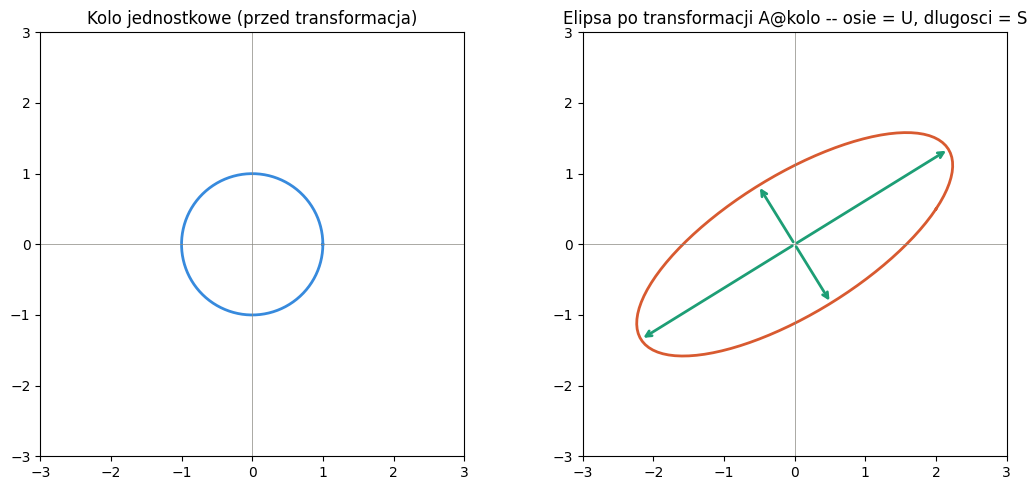

Singular values: [2.5583 0.9772]  <- dlugosci polosi elipsy


In [15]:
# --- Wizualizacja: jak A=U*Sigma*V^T transformuje okrag w elipse ---

A_2d = np.array([
    [2.0, 1.0],
    [0.5, 1.5],
])

U2, S2, Vt2 = np.linalg.svd(A_2d)

# Okrag jednostkowy (punkty na obwodzie)
theta = np.linspace(0, 2*np.pi, 100)
circle = np.vstack([np.cos(theta), np.sin(theta)])   # (2, 100)

# Transformacja przez A
ellipse = A_2d @ circle

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
ax.plot(circle[0], circle[1], color='#378ADD', linewidth=2)
ax.set_title('Kolo jednostkowe (przed transformacja)')
ax.set_aspect('equal')
ax.axhline(0, color='#888780', linewidth=0.5)
ax.axvline(0, color='#888780', linewidth=0.5)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

ax = axes[1]
ax.plot(ellipse[0], ellipse[1], color='#D85A30', linewidth=2)
# Rysujemy osie elipsy: kierunki to kolumny U, dlugosci to S
for i in range(2):
    direction = U2[:, i] * S2[i]
    ax.annotate('', xy=direction, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2))
    ax.annotate('', xy=-direction, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2))
ax.set_title('Elipsa po transformacji A@kolo -- osie = U, dlugosci = S')
ax.set_aspect('equal')
ax.axhline(0, color='#888780', linewidth=0.5)
ax.axvline(0, color='#888780', linewidth=0.5)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig('/tmp/svd_geometry.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Singular values: {S2.round(4)}  <- dlugosci polosi elipsy")


In [16]:
# --- Trzy kroki osobno: V^T (obrot) -> Sigma (skalowanie) -> U (obrot) ---

point = np.array([1.0, 0.0])   # punkt startowy na kole jednostkowym

step1 = Vt2 @ point             # obrot przez V^T
step2 = np.diag(S2) @ step1     # skalowanie przez Sigma
step3 = U2 @ step2              # obrot przez U

direct = A_2d @ point           # to samo bezposrednio

print(f"Punkt startowy:        {point}")
print(f"Po V^T (obrot):        {step1.round(4)}")
print(f"Po Sigma (skalowanie): {step2.round(4)}")
print(f"Po U (obrot):          {step3.round(4)}")
print(f"\nBezposrednio A@point:  {direct.round(4)}")
print(f"Identyczne: {np.allclose(step3, direct)}")


Punkt startowy:        [1. 0.]
Po V^T (obrot):        [-0.7678 -0.6407]
Po Sigma (skalowanie): [-1.9642 -0.6261]
Po U (obrot):          [2.  0.5]

Bezposrednio A@point:  [2.  0.5]
Identyczne: True


### 5.3 Singular values jako "wzmocnienie" w kazdym kierunku

Najwiekszy singular value $\sigma_1$ to **maksymalne mozliwe wzmocnienie** dlugosci
wektora pod dzialaniem $A$:

$$
\sigma_1 = \max_{\|\mathbf{x}\|=1} \|A\mathbf{x}\|
$$

To jest analogiczne do wyprowadzenia PCA z poprzedniego notebooka (`max w^T Sigma w`),
tylko teraz maksymalizujemy `||Ax||` zamiast wariancji. To jest tzw. **norma spektralna**
macierzy $A$ -- jeszcze jedna miara "wielkosci" macierzy, inna niz norma Frobeniusa.


In [17]:
# --- Weryfikacja: sigma_1 = max ||A x|| dla ||x||=1 ---

best_norm = -np.inf
for _ in range(100_000):
    x = np.random.normal(0, 1, 2)
    x = x / np.linalg.norm(x)   # normalizacja do dlugosci 1
    norm_Ax = np.linalg.norm(A_2d @ x)
    if norm_Ax > best_norm:
        best_norm = norm_Ax

print(f"Najwiekszy ||Ax|| znaleziony (brute-force, 100k prob): {best_norm:.6f}")
print(f"sigma_1 (z SVD):                                        {S2[0]:.6f}")
print(f"\nnp.linalg.norm(A, 2) (norma spektralna wprost):       {np.linalg.norm(A_2d, 2):.6f}")


Najwiekszy ||Ax|| znaleziony (brute-force, 100k prob): 2.558336
sigma_1 (z SVD):                                        2.558336

np.linalg.norm(A, 2) (norma spektralna wprost):       2.558336


---
## 6. Noise filtering -- kiedy to dziala, a kiedy nie

### 6.1 Idea (przypomnienie z kodu ktory juz mialej)

Zalozenie: prawdziwy "sygnal" w danych ma **niska range** (kilka dominujacych czynnikow),
a szum jest "plaski" -- rozlozony rownomiernie po wszystkich komponentach. Odciecie malych
singular values powinno usunac szum, zachowujac sygnal.

### 6.2 Test tego zalozenia: kontrolowany eksperyment

Zbudujemy dane gdzie **znamy** prawdziwy sygnal (bez szumu) i osobno dodany szum -- zeby
sprawdzic ile noise filtering faktycznie odzyskuje prawdziwy sygnal, a nie tylko "cos"
co wyglada gladko.


In [18]:
np.random.seed(7)

T, N = 504, 10

# Prawdziwy sygnal: DOKLADNIE 2 czynniki (bez szumu)
factor1 = np.random.normal(0, 0.01, T)
factor2 = np.random.normal(0, 0.008, T)
loadings1 = np.random.uniform(0.5, 1.5, N)
loadings2 = np.random.uniform(-1.0, 1.0, N)

true_signal = (loadings1[:, np.newaxis] * factor1[np.newaxis, :]
               + loadings2[:, np.newaxis] * factor2[np.newaxis, :]).T   # (T, N)

# Szum dodany NIEZALEZNIE
noise = np.random.normal(0, 0.006, (T, N))

observed = true_signal + noise   # to jest to co "widzimy" w praktyce

print(f"true_signal.shape: {true_signal.shape}")
print(f"Wariancja true_signal: {np.var(true_signal):.8f}")
print(f"Wariancja noise:        {np.var(noise):.8f}")
print(f"Wariancja observed:     {np.var(observed):.8f}  (powinna byc ~ sumie, bo niezalezne)")


true_signal.shape: (504, 10)
Wariancja true_signal: 0.00010372
Wariancja noise:        0.00003601
Wariancja observed:     0.00013963  (powinna byc ~ sumie, bo niezalezne)


In [19]:
# --- SVD filtering z K=2 (znamy ze prawdziwy sygnal ma rank 2) ---

def svd_reconstruct(U, S, Vt, K):
    return U[:, :K] * S[:K] @ Vt[:K, :]

observed_centered = observed - observed.mean(axis=0)
U_obs, S_obs, Vt_obs = np.linalg.svd(observed_centered, full_matrices=False)

K = 2
filtered_signal = svd_reconstruct(U_obs, S_obs, Vt_obs, K)

# Ile filtered_signal jest BLISKI true_signal (a nie tylko 'gladki')
true_signal_centered = true_signal - true_signal.mean(axis=0)

error_filtered_vs_true = np.linalg.norm(filtered_signal - true_signal_centered, 'fro')
error_observed_vs_true = np.linalg.norm(observed_centered - true_signal_centered, 'fro')

print(f"Blad: filtered_signal vs true_signal:  {error_filtered_vs_true:.6f}")
print(f"Blad: observed (niefiltrowane) vs true_signal: {error_observed_vs_true:.6f}")
print()
improvement = (1 - error_filtered_vs_true/error_observed_vs_true) * 100
print(f"Filtracja SVD zmniejszyla blad o {improvement:.1f}% wzgledem surowych danych")


Blad: filtered_signal vs true_signal:  0.195671
Blad: observed (niefiltrowane) vs true_signal: 0.425893

Filtracja SVD zmniejszyla blad o 54.1% wzgledem surowych danych


In [20]:
# --- A co jesli wybierzemy ZLE K? Test wplywu wyboru K na jakosc filtracji ---

print(f"{'K':>3} {'blad vs true_signal':>20} {'wariancja wyjasniana (%)':>26}")
print("-" * 55)
for K_test in [1, 2, 3, 4, 5, 8, 10]:
    filt = svd_reconstruct(U_obs, S_obs, Vt_obs, K_test)
    err  = np.linalg.norm(filt - true_signal_centered, 'fro')
    var_pct = (S_obs[:K_test]**2).sum() / (S_obs**2).sum() * 100
    marker = " <- prawdziwy rank sygnalu" if K_test == 2 else ""
    print(f"{K_test:>3} {err:>20.6f} {var_pct:>26.1f}{marker}")


  K  blad vs true_signal   wariancja wyjasniana (%)
-------------------------------------------------------
  1             0.263954                       69.5
  2             0.195671                       79.6 <- prawdziwy rank sygnalu
  3             0.244616                       82.7
  4             0.283376                       85.6
  5             0.316024                       88.4
  8             0.389770                       95.8
 10             0.425893                      100.0


### 6.3 Wniosek z eksperymentu

Minimalny blad wzgledem **prawdziwego** sygnalu wypada przy $K$ bliskim prawdziwej liczbie
czynnikow (tutaj 2) -- ale **nie zawsze dokladnie** w tym punkcie, bo szum w danych moze
przypadkowo "wstrzyknac" troche energii w PC3, PC4. Zbyt male $K$ odcina prawdziwy sygnal
(underfitting), zbyt duze $K$ pozwala szumowi wrocic (overfitting).

To jest powod czemu w praktyce nigdy nie znamy "prawdziwego" K z gory -- uzywa sie:
- scree plot (gdzie singular values "spadaja" wyraznie) -- jak w poprzednim notebooku PCA
- testow statystycznych (np. Marchenko-Pastur dla losowych macierzy, poza zakresem tego notebooka)
- wiedzy domenowej (np. "wiemy ze rynek ma 3-5 glownych czynnikow sektorowych")

### 6.4 Korelacja po filtracji -- dlaczego rosnie (z poprzedniego kodu)

Filtrowanie SVD **wzmacnia** wspolna strukture (te kilka dominujacych czynnikow) i usuwa
niezalezny szum. Skoro korelacja miedzy aktywami pochodzi GLOWNIE ze wspolnych czynnikow
(a nie z niezaleznego szumu), usuwajac szum **zwiekszamy wzgledny udzial** wspolnej
struktury -- stad wyzsza korelacja po filtracji. To NIE znaczy ze "prawdziwa" korelacja
jest wyzsza -- to znaczy ze odslonilismy czystszy obraz wspolnej struktury.


In [21]:
# --- Demonstracja na naszych kontrolowanych danych ---

corr_observed = np.corrcoef(observed_centered.T)
corr_filtered = np.corrcoef(filtered_signal.T)
corr_true     = np.corrcoef(true_signal_centered.T)   # "prawdziwa" korelacja (ground truth)

mask = ~np.eye(N, dtype=bool)

print("Srednia bezwzgledna korelacja miedzy aktywami:")
print(f"  Observed (z szumem):      {np.abs(corr_observed[mask]).mean():.4f}")
print(f"  Filtered (SVD, K=2):      {np.abs(corr_filtered[mask]).mean():.4f}")
print(f"  True signal (ground truth): {np.abs(corr_true[mask]).mean():.4f}")
print()
print("Filtracja przyblizyla korelacje do prawdziwej wartosci (ground truth),")
print("nie tylko 'zwiekszyla ja arbitralnie'.")


Srednia bezwzgledna korelacja miedzy aktywami:
  Observed (z szumem):      0.5811
  Filtered (SVD, K=2):      0.8497
  True signal (ground truth): 0.8873

Filtracja przyblizyla korelacje do prawdziwej wartosci (ground truth),
nie tylko 'zwiekszyla ja arbitralnie'.


---
## 7. Dalej z materialem: pseudoinverse i rozwiazywanie ukladow rownan

### 7.1 Problem: regresja liniowa kiedy macierz nie jest kwadratowa

Klasyczny problem: masz uklad $A\mathbf{x} = \mathbf{b}$ gdzie $A$ jest $(m \times n)$
z $m \neq n$ (np. wiecej obserwacji niz zmiennych -- typowa regresja). Zwykla odwrotnosc
$A^{-1}$ **nie istnieje** dla macierzy nie-kwadratowej.

### 7.2 Pseudoinverse (Moore-Penrose) przez SVD

Definiujemy pseudoinverse $A^+$ uzywajac SVD $A = U\Sigma V^T$:

$$
A^+ = V \Sigma^+ U^T
$$

gdzie $\Sigma^+$ to transpozycja $\Sigma$ z **odwroconymi niezerowymi** wartosciami
($1/\sigma_i$ zamiast $\sigma_i$, zera pozostaja zerami).

Rozwiazanie najmniejszych kwadratow ($\min \|A\mathbf{x}-\mathbf{b}\|^2$) to:

$$
\mathbf{x}^* = A^+ \mathbf{b}
$$

To jest **uogolnienie** standardowej regresji liniowej $\hat\beta = (X^TX)^{-1}X^Ty$ --
pseudoinverse dziala nawet gdy $X^TX$ jest singularna (np. perfekcyjna multikolinearnosc
miedzy zmiennymi).


In [22]:
# --- Przyklad: regresja liniowa przez pseudoinverse, porownanie z formula standardowa ---

np.random.seed(42)
n_obs, n_features = 100, 3

X = np.random.normal(0, 1, (n_obs, n_features))
true_beta = np.array([2.0, -1.5, 0.5])
y = X @ true_beta + np.random.normal(0, 0.1, n_obs)   # z szumem

# Metoda 1: standardowa formula (X^T X)^-1 X^T y
beta_standard = np.linalg.inv(X.T @ X) @ X.T @ y

# Metoda 2: pseudoinverse przez SVD
X_pinv = np.linalg.pinv(X)   # numpy liczy to wewnetrznie przez SVD
beta_pinv = X_pinv @ y

print("True beta:        ", true_beta)
print("Standardowa formula:", beta_standard.round(4))
print("Pseudoinverse:       ", beta_pinv.round(4))
print(f"\nIdentyczne: {np.allclose(beta_standard, beta_pinv)}")


True beta:         [ 2.  -1.5  0.5]
Standardowa formula: [ 1.9937 -1.5069  0.4898]
Pseudoinverse:        [ 1.9937 -1.5069  0.4898]

Identyczne: True


In [23]:
# --- Reczna implementacja pseudoinverse przez SVD (zeby zobaczyc co numpy robi w srodku) ---

U, S, Vt = np.linalg.svd(X, full_matrices=False)

# Sigma^+ to po prostu 1/sigma_i dla niezerowych sigma_i
S_pinv = np.where(S > 1e-10, 1/S, 0)   # zabezpieczenie przed dzieleniem przez ~0

# A^+ = V Sigma^+ U^T
X_pinv_manual = (Vt.T * S_pinv) @ U.T   # broadcasting: Vt.T (n,k) * S_pinv (k,) potem @ U.T

beta_manual = X_pinv_manual @ y

print("Pseudoinverse (recznie z SVD):", beta_manual.round(4))
print("Pseudoinverse (np.linalg.pinv):", beta_pinv.round(4))
print(f"Identyczne: {np.allclose(beta_manual, beta_pinv)}")


Pseudoinverse (recznie z SVD): [ 1.9937 -1.5069  0.4898]
Pseudoinverse (np.linalg.pinv): [ 1.9937 -1.5069  0.4898]
Identyczne: True


### 7.3 Kiedy pseudoinverse jest niezbedne: macierz singularna

Pokazmy przypadek gdzie standardowa formula **zawodzi** (macierz singularna -- perfekcyjna
korelacja miedzy zmiennymi), a pseudoinverse wciaz daje sensowna odpowiedz.


In [24]:
# --- Macierz z perfekcyjna multikolinearnoscia ---

X_singular = np.random.normal(0, 1, (50, 3))
X_singular[:, 2] = X_singular[:, 0] + X_singular[:, 1]   # kolumna 3 = suma 1 i 2 (zalezna!)

y_singular = X_singular[:, 0] * 2 + X_singular[:, 1] * (-1) + np.random.normal(0, 0.01, 50)

print("Probujemy standardowej formuly (X^T X)^-1 ...")
try:
    XtX = X_singular.T @ X_singular
    print(f"det(X^T X) = {np.linalg.det(XtX):.2e}  <- bliskie zeru, macierz (prawie) singularna")
    beta_bad = np.linalg.inv(XtX) @ X_singular.T @ y_singular
    print(f"Wynik: {beta_bad.round(4)}  <- moze byc niestabilny numerycznie")
except np.linalg.LinAlgError as e:
    print(f"BLAD: {e}")

print()
print("Pseudoinverse (stabilne, dziala mimo singularnosci):")
beta_pinv_singular = np.linalg.pinv(X_singular) @ y_singular
print(f"Wynik: {beta_pinv_singular.round(4)}")
print()
print("Pseudoinverse wybiera rozwiazanie o NAJMNIEJSZEJ normie wsrod wszystkich")
print("rozwiazan ktore minimalizuja blad -- to jest dodatkowa, uzyteczna wlasnosc.")


Probujemy standardowej formuly (X^T X)^-1 ...
det(X^T X) = 0.00e+00  <- bliskie zeru, macierz (prawie) singularna
BLAD: Singular matrix

Pseudoinverse (stabilne, dziala mimo singularnosci):
Wynik: [ 1.6653 -1.3313  0.334 ]

Pseudoinverse wybiera rozwiazanie o NAJMNIEJSZEJ normie wsrod wszystkich
rozwiazan ktore minimalizuja blad -- to jest dodatkowa, uzyteczna wlasnosc.


---
## 8. Dalej z materialem: SVD w systemach rekomendacji

### 8.1 Klasyczne zastosowanie poza finansami

SVD jest fundamentem systemow rekomendacji typu **collaborative filtering** (np. wczesny
Netflix Prize). Idea: masz macierz `user x item` z ocenami (np. ratingi filmow), w wiekszosci
**pusta** (uzytkownicy nie ocenili wiekszosci filmow). SVD znajduje **ukryte czynniki**
(latent factors) ktore wyjasniaja preferencje.

### 8.2 Analogia z finansami

To jest **dokladnie ten sam mechanizm** co noise filtering z Sekcji 6 -- tylko teraz
"uzupelniamy" brakujace dane zamiast usuwac szum. Macierz `returns_big` (dni x aktywa)
jest analogiczna do macierzy `user x item` -- w obu przypadkach szukamy niskiej rangi
struktury ktora wyjasnia obserwowane dane.


In [25]:
# --- Mini system rekomendacji: SVD do uzupelniania brakujacych ocen ---

np.random.seed(3)
n_users, n_items = 8, 6

# Prawdziwe oceny: generowane z 2 ukrytych czynnikow (np. 'lubi akcje' / 'lubi komedie')
user_factors = np.random.normal(0, 1, (n_users, 2))
item_factors = np.random.normal(0, 1, (n_items, 2))
true_ratings = user_factors @ item_factors.T + 3   # +3 zeby oceny byly w sensownym zakresie

# Symulujemy ze tylko 60% ocen jest znanych (reszta brakuje)
mask_known = np.random.random((n_users, n_items)) < 0.6
observed_ratings = np.where(mask_known, true_ratings, np.nan)

print("Obserwowane oceny (NaN = brak danych):")
print(np.round(observed_ratings, 2))


Obserwowane oceny (NaN = brak danych):
[[  nan   nan   nan   nan  0.86  4.05]
 [  nan  5.15  3.27  2.7   4.23  3.36]
 [ 3.7   3.12  3.4    nan  3.54  2.88]
 [ 4.01  3.61  3.23  2.73  3.53  3.05]
 [ 3.76  3.48   nan   nan   nan   nan]
 [ 2.35   nan  4.38  1.26  3.71  2.04]
 [-0.12  1.98   nan  4.71   nan   nan]
 [  nan  3.49  3.02  2.98  3.24  3.1 ]]


In [26]:
# --- Prosty algorytm: wypelnij NaN srednia, zrob SVD, zatrzymaj K=2, iteruj ---
# (To jest uproszczona wersja "matrix completion via SVD" -- prawdziwe systemy
#  uzywaja bardziej zaawansowanych metod, ale idea jest identyczna)

R = observed_ratings.copy()
global_mean = np.nanmean(R)
R_filled = np.where(np.isnan(R), global_mean, R)   # pierwsze wypelnienie srednia

K = 2
for iteration in range(50):
    R_centered_iter = R_filled - R_filled.mean()
    U_r, S_r, Vt_r = np.linalg.svd(R_centered_iter, full_matrices=False)

    # Rekonstrukcja rank-K
    R_approx = (U_r[:, :K] * S_r[:K]) @ Vt_r[:K, :] + R_filled.mean()

    # Aktualizujemy TYLKO brakujace wartosci, znane oceny zostawiamy bez zmian
    R_filled = np.where(mask_known, R, R_approx)

print("Po 50 iteracjach rekonstrukcji SVD (rank=2):")
print(np.round(R_filled, 2))
print()
print("Prawdziwe oceny (ground truth):")
print(np.round(true_ratings, 2))
print()

error_unknown = np.abs(R_filled[~mask_known] - true_ratings[~mask_known]).mean()
print(f"Sredni blad absolutny na BRAKUJACYCH ocenach: {error_unknown:.4f}")


Po 50 iteracjach rekonstrukcji SVD (rank=2):
[[ 0.35  3.03  1.24  6.33  0.86  4.05]
 [ 6.84  5.15  3.27  2.7   4.23  3.36]
 [ 3.7   3.12  3.4   2.51  3.54  2.88]
 [ 4.01  3.61  3.23  2.73  3.53  3.05]
 [ 3.76  3.48  3.11  3.07  3.3   3.19]
 [ 2.35  1.71  4.38  1.26  3.71  2.04]
 [-0.12  1.98  2.28  4.71  1.55  3.37]
 [ 3.74  3.49  3.02  2.98  3.24  3.1 ]]

Prawdziwe oceny (ground truth):
[[ 1.35  4.28  0.79  5.76  0.86  4.05]
 [ 5.83  5.15  3.27  2.7   4.23  3.36]
 [ 3.7   3.12  3.4   2.5   3.54  2.88]
 [ 4.01  3.61  3.23  2.73  3.53  3.05]
 [ 3.76  3.48  3.15  2.82  3.39  3.05]
 [ 2.35  0.74  4.38  1.26  3.71  2.04]
 [-0.12  1.98  1.6   4.71  0.88  3.28]
 [ 3.6   3.49  3.02  2.98  3.24  3.1 ]]

Sredni blad absolutny na BRAKUJACYCH ocenach: 0.4903


In [27]:
# --- Porownanie z naiwna metoda (wypelnienie tylko srednia, bez SVD) ---

naive_fill = np.where(mask_known, R, global_mean)
error_naive = np.abs(naive_fill[~mask_known] - true_ratings[~mask_known]).mean()

print(f"Blad SVD (rank=2):        {error_unknown:.4f}")
print(f"Blad naiwny (sama srednia): {error_naive:.4f}")
print(f"\nSVD lepsze: {error_unknown < error_naive}")
print()
print("To jest istota systemow rekomendacji: SVD wykorzystuje STRUKTURE")
print("(podobni uzytkownicy oceniaja podobnie) zamiast zgadywac 'na sredniej'.")


Blad SVD (rank=2):        0.4903
Blad naiwny (sama srednia): 1.2460

SVD lepsze: True

To jest istota systemow rekomendacji: SVD wykorzystuje STRUKTURE
(podobni uzytkownicy oceniaja podobnie) zamiast zgadywac 'na sredniej'.


---
## Podsumowanie

In [28]:
summary = '''
+===================================================================+
|         SVD -- PODSUMOWANIE WZOROW I ZASTOSOWAN                  |
+===================================================================+
| DEFINICJA                                                          |
|   A = U Sigma V^T     dla KAZDEJ macierzy A (m x n), nie tylko    |
|                        kwadratowej/symetrycznej                   |
|   U: (m x m) ortogonalna     V: (n x n) ortogonalna               |
|   Sigma: (m x n) diagonalna, sigma_1 >= sigma_2 >= ... >= 0       |
+===================================================================+
| ISTNIENIE                                                          |
|   A^T A jest symetryczna i PSD  =>  ma dekompozycje spektralna    |
|   sigma_i = sqrt(eigenvalue_i z A^T A)                             |
+===================================================================+
| THIN VS FULL SVD (numpy)                                          |
|   full_matrices=True:  U(m,m), S(k,), Vt(n,n)                    |
|   full_matrices=False: U(m,k), S(k,), Vt(k,n),  k=min(m,n)        |
|   S jest WEKTOREM w obu wersjach -- np.diag(S) by zrobic macierz |
+===================================================================+
| ZWIAZEK Z PCA / KOWARIANCJA                                       |
|   Dla R_centered (T x N):  Sigma_cov = (1/(T-1)) R_c^T R_c        |
|   eigenvalues(Sigma_cov) = S^2 / (T-1)                             |
|   eigenvectors(Sigma_cov) = V (right singular vectors)            |
|   PC scores = R_c @ V = U * S  (broadcasting)                     |
+===================================================================+
| REKONSTRUKCJA LOW-RANK (Eckart-Young)                              |
|   A_K = sum_{i=1}^K sigma_i u_i v_i^T = U_K Sigma_K V_K^T          |
|   A_K to NAJLEPSZA aproksymacja rangi K w normie Frobeniusa       |
|   ||A - A_K||_F = sqrt(sum_{i>K} sigma_i^2)                        |
|   UWAGA: "wariancja" = sum(sigma_K^2)/sum(sigma^2)                |
|          to NIE to samo co 1 - ||error||/||total||                |
+===================================================================+
| GEOMETRIA                                                           |
|   A = obrot(V^T) -> skalowanie(Sigma) -> obrot(U)                 |
|   sigma_1 = max ||Ax|| dla ||x||=1   (norma spektralna)           |
+===================================================================+
| NOISE FILTERING                                                    |
|   Male sigma_i ~ szum, duze sigma_i ~ sygnal                      |
|   Odciecie do K skladnikow redukuje szum JESLI prawdziwy K        |
|   jest mniejszy -- wybor K to kompromis under/overfitting        |
+===================================================================+
| PSEUDOINVERSE (Moore-Penrose)                                     |
|   A^+ = V Sigma^+ U^T   (Sigma^+ : odwrocone NIEZEROWE sigma_i)  |
|   dziala nawet gdy A^T A jest singularna                          |
|   x* = A^+ b  rozwiazuje min ||Ax - b||^2                         |
+===================================================================+
| ZASTOSOWANIE: SYSTEMY REKOMENDACJI                                |
|   matrix completion: SVD rank-K + iteracyjne wypelnianie NaN      |
|   wykorzystuje ukryta strukture (latent factors) danych           |
+===================================================================+
'''
print(summary)



+===================================================================+
|         SVD -- PODSUMOWANIE WZOROW I ZASTOSOWAN                  |
+===================================================================+
| DEFINICJA                                                          |
|   A = U Sigma V^T     dla KAZDEJ macierzy A (m x n), nie tylko    |
|                        kwadratowej/symetrycznej                   |
|   U: (m x m) ortogonalna     V: (n x n) ortogonalna               |
|   Sigma: (m x n) diagonalna, sigma_1 >= sigma_2 >= ... >= 0       |
+===================================================================+
| ISTNIENIE                                                          |
|   A^T A jest symetryczna i PSD  =>  ma dekompozycje spektralna    |
|   sigma_i = sqrt(eigenvalue_i z A^T A)                             |
+===================================================================+
| THIN VS FULL SVD (numpy)                                          |
|   full_matrices